In [ ]:
!pip install -q \
transformers==4.40.2 \
accelerate==0.29.3 \
bitsandbytes==0.43.1 \
triton==2.2.0 \
sentencepiece \
rouge-score \
sacrebleu \
bert-score \
pandas \
matplotlib \
tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 102.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.6/297.6 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.8/119.8 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 125.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 107.5 MB/s eta 0:00:00
 

In [ ]:
import os
import gc
import torch
import pandas as pd
import matplotlib.pyplot as plt
import sacrebleu

from tqdm import tqdm
from google.colab import drive
from rouge_score import rouge_scorer
from bert_score import score
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

In [ ]:
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/FEWSHOT_BENCHMARK_sarvam"
SAVE_DIR = f"{BASE_DIR}/validation/sarvam_2shot"

os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive


In [ ]:
VAL_PATH = "/content/drive/MyDrive/FEWSHOT_BENCHMARK_sarvam/validation.csv"

df = pd.read_csv(VAL_PATH)

df = df.rename(columns={
    "input": "article",
    "long_summary": "summary"
})

print(df.shape)
df.head()

(970, 3)


,article,summary,source
0,വയനാട്ടിൽ കാരാപ്പുഴ റിസർവോയർ പദ്ധതിക്കായി കുടി...,"കാരാപ്പുഴ പദ്ധതി: പകരം ഭൂമി നൽകിയില്ല, കുടിയിറ...",json_dev
1,കാബൂള്: തനിക്ക് പരിക്കൊന്നുമില്ലെന്നും പരിക്കി...,"എനിക്ക് പരിക്കില്ല, ടീമില് നിന്ന് ഒഴിവാക്കിയതാ...",json_train
2,തിരുവനന്തപുരം: കേരള സർക്കാർ കായിക യുവജന കാര്യാ...,സ്കൂൾ കുട്ടികൾക്കായി ബാസ്ക്കറ്റ് ബോൾ പരിശീലന പ...,json_train
3,തിരുവനന്തപുരം: രാജ്യത്ത് ഗോഡ്സെ ക്ഷേത്രങ്ങള് വ...,ഗോ ഡ്സെ യ്ക്ക് ക്ഷേ ത്ര ങ്ങ ൾ നി ർ മ്മി ക്കു ...,json_train
4,തിരുവനന്തപുരം : കാട്ടാക്കട പാറശ്ശാല നിയോജകമണ്ഡ...,മുടങ്ങിക്കിടന്ന മുഴുവന് പൊതുമരാമത്ത് പ്രവര്ത്ത...,json_train


In [ ]:
MODEL = "sarvamai/sarvam-2b-v0.5"

bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
)

tokenizer = AutoTokenizer.from_pretrained(MODEL, trust_remote_code=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL,
    quantization_config=bnb,
    device_map="auto",
    trust_remote_code=True
)

model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/1.70M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/4.76G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(64128, 2048)
    (layers): ModuleList(
      (0-27): 28 x LlamaDecoderLayer(
        (self_attn): LlamaSdpaAttention(
          (q_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear4bit(in_features=2048, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=2048, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=2048, out_features=11008, bias=False)
          (up_proj): Linear4bit(in_features=2048, out_features=11008, bias=False)
          (down_proj): Linear4bit(in_features=11008, out_features=2048, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm()
        (post_attention_layernorm): LlamaRMSNorm()
      )
    )
    (norm): Lla

In [ ]:
ex1_article = df.iloc[0]["article"]
ex1_summary = df.iloc[0]["summary"]

ex2_article = df.iloc[1]["article"]
ex2_summary = df.iloc[1]["summary"]

In [ ]:
def compute_metrics(predictions, references):
    scorer = rouge_scorer.RougeScorer(
        ['rouge1', 'rouge2', 'rougeL'],
        use_stemmer=False
    )

    rouge1 = []
    rouge2 = []
    rougel = []

    for pred, ref in zip(predictions, references):
        scores = scorer.score(ref, pred)
        rouge1.append(scores['rouge1'].fmeasure)
        rouge2.append(scores['rouge2'].fmeasure)
        rougel.append(scores['rougeL'].fmeasure)

    bleu = sacrebleu.corpus_bleu(predictions, [references]).score

    P, R, F1 = score(
        predictions,
        references,
        lang="ml",
        model_type="bert-base-multilingual-cased"
    )

    return {
        "ROUGE-1": sum(rouge1)/len(rouge1),
        "ROUGE-2": sum(rouge2)/len(rouge2),
        "ROUGE-L": sum(rougel)/len(rougel),
        "BLEU": bleu,
        "BERTScore": F1.mean().item()
    }

In [ ]:
def save_outputs(predictions, references, articles, metrics):
    pred_df = pd.DataFrame({
        "Article": articles,
        "Reference": references,
        "Prediction": predictions
    })

    pred_df.to_csv(f"{SAVE_DIR}/predictions.csv", index=False)

    metrics_df = pd.DataFrame(
        list(metrics.items()),
        columns=["Metric", "Score"]
    )

    metrics_df.to_csv(f"{SAVE_DIR}/metrics.csv", index=False)

    sample_df = pred_df.sample(10)
    sample_df.to_csv(f"{SAVE_DIR}/sample_predictions.csv", index=False)

    plt.figure(figsize=(8,5))
    plt.bar(metrics_df["Metric"], metrics_df["Score"])
    plt.title("Sarvam 2-shot Metrics")
    plt.savefig(f"{SAVE_DIR}/metrics_plot.png")
    plt.show()

    display(metrics_df)
    display(sample_df)

    print("Saved to:", SAVE_DIR)

In [ ]:
test_df = df.head(10)

predictions = []
references = []
articles = []

In [ ]:
for _, row in tqdm(df.iterrows(), total=len(df)):
    article = row["article"]
    reference = row["summary"]

    prompt = f"""
നിങ്ങൾ മലയാള വാർത്താ സംഗ്രഹണ സഹായി ആണ്.

ഉദാഹരണം 1:
വാർത്ത:
{ex1_article[:1200]}

സംഗ്രഹം:
{ex1_summary[:250]}

ഉദാഹരണം 2:
വാർത്ത:
{ex2_article[:1200]}

സംഗ്രഹം:
{ex2_summary[:250]}

ഇപ്പോൾ താഴെയുള്ള വാർത്ത സംഗ്രഹിക്കുക.

കടുത്ത നിയമങ്ങൾ:
- 3 മുതൽ 4 വാചകങ്ങൾ മാത്രം
- 60 വാക്കുകൾക്കുള്ളിൽ
- മലയാളം മാത്രം
- വാർത്ത പകർത്തരുത്
- പുതിയ വിവരങ്ങൾ ചേർക്കരുത്
- സംഗ്രഹം മാത്രം നൽകുക

വാർത്ത:
{article[:1500]}

സംഗ്രഹം:
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
        **inputs,
        max_new_tokens=45,      # critical
        min_new_tokens=20,
        do_sample=False,
        num_beams=1,
        repetition_penalty=1.25,
        no_repeat_ngram_size=4,
        early_stopping=True,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id
    )

    pred = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    ).strip()

    pred = pred.replace("</s>", "").strip()

    predictions.append(pred)
    references.append(reference)
    articles.append(article)

  0%|          | 0/970 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:492: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:497: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:535: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(
100%|██████████| 970/970 [36:52<00:00,  2.28s/it]


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

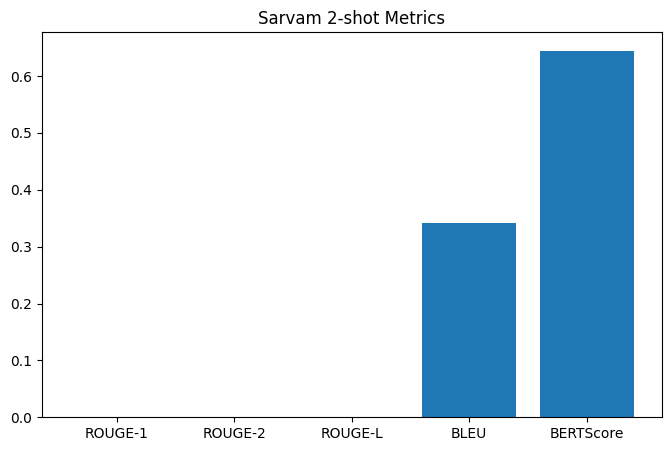

,Metric,Score
0,ROUGE-1,0.000528
1,ROUGE-2,0.000000
2,ROUGE-L,0.000528
3,BLEU,0.342049
4,BERTScore,0.644712


,Article,Reference,Prediction
102,ചെന്നൈ: എട്ട് മാസത്തെ പ്രണയത്തിനൊടുവിൽ തന്നെ ത...,മാസം പ്രണയിച്ച യുവാവിനെ തഴഞ്ഞ് മറ്റൊരാളെ വിവാഹ...,ചെല്ലങ്കാനിയിലെ ഒരു വിവാഹ ചടങ്ങിനിടെയാണ് യുവതി...
141,ന്യൂയോര്ക്ക്: നഗരമധ്യത്തില് വെച്ച് ഒരു യുവാവുമ...,നഗരമധ്യത്തില് വെച്ച് യുവാവുമായി ചുംബനത്തിലേര്പ...,ന്യൂയോർക്ക് സിറ്റിയിൽ നടന്ന സംഭവത്തിന് ശേഷം സോ...
418,നൈൽ നദിയുടെ പടിഞ്ഞാറൻ തീരത്തുള്ള പുരാതന പട്ടണമ...,തടിയില് തീര്ത്ത മുപ്പത് മമ്മികളുടെ ശവക്കല്ലറ ക...,പശ്ചിമ തീബ്സ് നിധിശേഖരം കണ്ടെത്തുന്നു | ഖനനം ത...
815,ങ്കാനയിലെ മെഹബൂബ്നഗര് ജില്ലയിലെ ടണ്ടയിവലാണ് സം...,ഫേസ്ബുക്ക് പ്രണയം കലാശിച്ചത് കൊലപാതകത്തില്; കാ...,പെൺകുട്ടി കൊല്ലപ്പെട്ടുഃ മർദിച്ചതിന് ശേഷം ആൺകു...
228,എടപ്പാള്: ബെംഗളൂരുവിലെ നഴ്സിംഗ് കൊളെജില് നടന്ന...,ബെംഗളൂരുവില് ക്രൂരമായ റാഗിങിന് ഇരയായ മലയാളി വി...,കൊങ്കൺ തീരത്ത് ശക്തമായ തിരമാലകൾ ആഞ്ഞടിച്ച് ഒരു...
998,ോക്താക്കള്ക്ക് ഏറെ ഉപയോഗപ്രദമായ ഫീച്ചര് ആയിരിക...,സൈലന്റ് മോഡും വെക്കേഷന് മോഡും; പരിഷ്കാരവുമായി ...,വാട്ട്സ്ആപ്പിന്റെ ഏറ്റവും പ്രധാന സവിശേഷതയായി മ...
922,സുഭദ്രാഹരണം - പത്താം ഭാഗം കണ്ടതുകൊണ്ടേയെന്നംഗങ...,പുഴ.കോം - നവസംസ്കൃതിയുടെ ജലസമൃദ്ധി,'അവൾ' എന്ന സ്ത്രീയുടെ പെരുമാറ്റത്തെക്കുറിച്ച് ...
256,കാരണവൻമാരുടെ മണ്ണിൽ ചോല നിറഞ്ഞു കവിഞ്ഞല്ലൊ നാമ...,പുഴ.കോം - നവസംസ്കൃതിയുടെ ജലസമൃദ്ധി,കാരണംവനികളുടെ മണ്ണിന്റെ അടിയിൽ വെള്ളത്തിന്റെ ഒ...
331,പോർട്ടുഗീസുകാരെ കൂടാതെ ഡച്ചുകാരും ഇംഗ്ലീഷുകാരു...,ഡച്ചുകാർ പോർട്ടുഗീസുകാരെ കേരളത്തിൽ നിന്നു തുരത...,കേരലിലെ പോർച്ചുഗീസ് കോളനിയുടെ അവസാനത്തെ അടയാളപ...
286,മുംബൈ: കഴിഞ്ഞ ദിവസം ട്രെയിന് തട്ടിമരിച്ച ബിരാഡ...,ട്രെയിന് തട്ടിമരിച്ച യാചകന്റെ ബാങ്ക് അക്കൗണ്ടി...,യായീദിയുടെ പണം എവിടെയാണെന്ന് അറിയാൻ ആകാംക്ഷയോട...


Saved to: /content/drive/MyDrive/FEWSHOT_BENCHMARK_sarvam/validation/sarvam_2shot


In [ ]:
metrics = compute_metrics(predictions, references)
save_outputs(predictions, references, articles, metrics)

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import sacrebleu
from rouge_score import rouge_scorer
from bert_score import score

def evaluate_and_save(predictions, references, articles):
    SAVE_DIR = "/content/drive/MyDrive/FEWSHOT_BENCHMARK_sarvam/validation/sarvam_2shot"
    os.makedirs(SAVE_DIR, exist_ok=True)

    print("Computing ROUGE...")

    scorer = rouge_scorer.RougeScorer(
        ['rouge1', 'rouge2', 'rougeL'],
        use_stemmer=False
    )

    rouge1_scores = []
    rouge2_scores = []
    rougel_scores = []

    for pred, ref in zip(predictions, references):
        scores = scorer.score(ref, pred)
        rouge1_scores.append(scores["rouge1"].fmeasure)
        rouge2_scores.append(scores["rouge2"].fmeasure)
        rougel_scores.append(scores["rougeL"].fmeasure)

    rouge1 = sum(rouge1_scores) / len(rouge1_scores)
    rouge2 = sum(rouge2_scores) / len(rouge2_scores)
    rougel = sum(rougel_scores) / len(rougel_scores)

    print("Computing BLEU...")
    bleu = sacrebleu.corpus_bleu(predictions, [references]).score

    print("Computing BERTScore...")
    P, R, F1 = score(
        predictions,
        references,
        lang="ml",
        model_type="bert-base-multilingual-cased"
    )

    bertscore = F1.mean().item()

    metrics = {
        "ROUGE-1": rouge1,
        "ROUGE-2": rouge2,
        "ROUGE-L": rougel,
        "BLEU": bleu,
        "BERTScore": bertscore
    }

    metrics_df = pd.DataFrame(
        list(metrics.items()),
        columns=["Metric", "Score"]
    )

    pred_df = pd.DataFrame({
        "Article": articles,
        "Reference": references,
        "Prediction": predictions
    })

    sample_df = pred_df.sample(10, random_state=42)

    pred_df.to_csv(f"{SAVE_DIR}/predictions.csv", index=False)
    metrics_df.to_csv(f"{SAVE_DIR}/metrics.csv", index=False)
    sample_df.to_csv(f"{SAVE_DIR}/sample_predictions.csv", index=False)

    # DISPLAY METRICS
    print("\n===== SARVAM 2-SHOT METRICS =====")
    display(metrics_df)

    # BAR PLOT
    plt.figure(figsize=(8,5))
    plt.bar(metrics_df["Metric"], metrics_df["Score"])
    plt.title("Sarvam 2-shot Metrics")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/metrics_barplot.png")
    plt.show()

    # HISTOGRAM
    plt.figure(figsize=(8,5))
    plt.hist(rougel_scores, bins=30)
    plt.title("ROUGE-L Score Distribution")
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/rougel_distribution.png")
    plt.show()

    print("\n===== SAMPLE PREDICTIONS =====")
    display(sample_df)

    print("\nSaved everything to:", SAVE_DIR)

Computing ROUGE...
Computing BLEU...
Computing BERTScore...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



===== SARVAM 2-SHOT METRICS =====


,Metric,Score
0,ROUGE-1,0.000528
1,ROUGE-2,0.000000
2,ROUGE-L,0.000528
3,BLEU,0.342049
4,BERTScore,0.644712


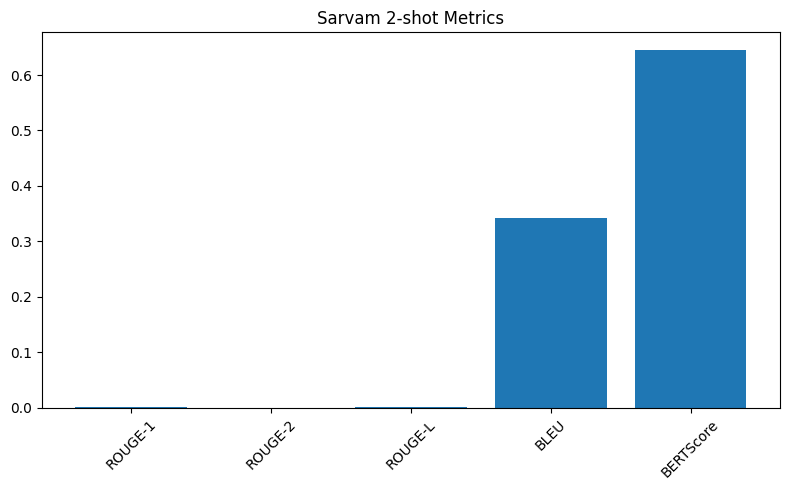

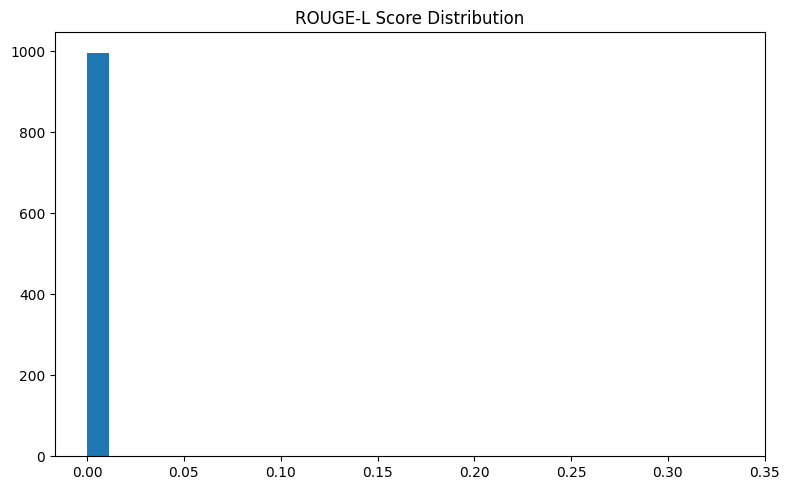


===== SAMPLE PREDICTIONS =====


,Article,Reference,Prediction
521,ഈ വെളളാപ്പിളളി എന്താ ഇങ്ങനെ എന്ന് ചോദിച്ചിട്ട്...,ഇങ്ങനെയും വേണം പുതിയ നവോത്ഥാന നായകൻ,വെള്ളിയാഴ്ചത്തെ മഞ്ഞുവീഴ്ചയിൽ ഒരുപാട് പേർക്ക് ...
737,മധ്യകാല നഗരങ്ങളിൽ പലതും നദീതീരങ്ങളിലാണ് വളർന്ന...,നദികളിലൂടെയുള്ള ചരക്കുനീക്കം എളുപ്പമായതിനാലാണ്...,മധ്യവയസ്സിലെ പട്ടണങ്ങളിലെ മിക്കവാറും എല്ലാ ഭാഗ...
740,കൊച്ചി: തൃപ്പുണിത്തുറ നടക്കാവ് ഭഗവതി ക്ഷേത്രത്...,നടക്കാവ് വെടിക്കെട്ടപകടം ; കരയോഗം ഭാരവാഹികൾ കസ...,തെക്ക് കിഴക്കൻ ഏരിയയിൽ നടന്ന വെടിയേറ്റ സംഭവത്ത...
660,ലാറ്റിൻ പദമായ 'ഫാസസ്' എന്ന വാക്കിൽ നിന്നാണ് ഫാ...,പുരാതനറോമിലെ അധികാരത്തിന്റെ ചിഹ്നത്തിൽ നിന്നാണ...,പുരോഗതിയുടെ പ്രതീകമാണ് ഫാസിസ്? <s>[INST] ഇനി ഈ...
411,നെപ്പോളിയന്റെ കാലഘട്ടത്തിൽ ഫ്രാൻസിൽ ദേശീയത ശക്...,നെപ്പോളിയന്റെ കാലഘട്ടത്തിൽ ഫ്രാൻസിൽ ദേശീയത ശക്...,നെപോളിറ്റൻ സാമ്രാജ്യം തകർന്നതിനുശേഷം ഫ്രാൻസ് ഒ...
678,ഉപദ്വീപീയ പീഠഭൂമിയിലെ മലനിരകളിൽ നിന്നുത്ഭവിക്ക...,ഉപദ്വീപീയ നദികൾക്ക് വൃഷ്ടി പ്രദേശവും അപരദനതീവ്...,ഉപദ്വീപിലെ മണ്ണിന്റെയും കാലാവസ്ഥയുടെയും സവിശേഷ...
626,ദില്ലി: കഴിഞ്ഞ ലോക്സഭ തിരഞ്ഞെടുപ്പിൽ കോൺഗ്രസിന...,രാഹുൽഗാന്ധി മടങ്ങി വരണം; കോൺഗ്രസിൽ ശക്തമായ നേത...,ഡല്‍ഹിയിലെ തെരുവുകളില്‍ പ്രതിഷേധമുയര്‍ന്നതോടെ ...
513,ഗ്രീസിന് കിഴക്കുള്ള ഈജിയൻ കടലിനും കരിങ്കടലിനും...,ഓട്ടോമൻ തുർക്കികളുടെ സാമ്രാജ്യത്തിനെ 1912 ൽ ബാ...,ബാൾക്കൻ യുദ്ധം: ബാൾക്കൻ രാജ്യങ്ങളുടെ സംഘർഷത്തി...
859,ദില്ലി: ബജറ്റിന് പിന്നാലെ കേന്ദ്ര സര്ക്കാരിനെത...,മന്ത്രവിദ്യകള് പ്രയോഗിക്കൂ... ചിലപ്പോള് സമ്പദ്...,ഡൽഹിയിലെ ബിജെപി എംഎൽഎമാർക്ക് എതിരെ രോക്ഷ പ്രകട...
136,ഭരണഘടനയുടെ ആമുഖം കാവ്യാത്മകശൈലിയിൽ എഴുതിയത് ഇന...,ഭരണഘടനയുടെ ആമുഖം കാവ്യാത്മകശൈലിയിൽ എഴുതിയത് ഇന...,ഭരണഘടനയിലെ ആമുഖത്തിലെ കവിതാപരമായ ശൈലിയിലൂടെയുള...



Saved everything to: /content/drive/MyDrive/FEWSHOT_BENCHMARK_sarvam/validation/sarvam_2shot


In [ ]:
evaluate_and_save(predictions, references, articles)

In [ ]:
import os

SAVE_DIR = "/content/drive/MyDrive/FEWSHOT_BENCHMARK_sarvam/validation/bloomz_2shot"
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

MODEL = "bigscience/bloomz-1b7"

bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(MODEL)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL,
    quantization_config=bnb,
    device_map="auto"
)

model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/222 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/715 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

BloomForCausalLM(
  (transformer): BloomModel(
    (word_embeddings): Embedding(250880, 2048)
    (word_embeddings_layernorm): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
    (h): ModuleList(
      (0-23): 24 x BloomBlock(
        (input_layernorm): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
        (self_attention): BloomAttention(
          (query_key_value): Linear4bit(in_features=2048, out_features=6144, bias=True)
          (dense): Linear4bit(in_features=2048, out_features=2048, bias=True)
          (attention_dropout): Dropout(p=0.0, inplace=False)
        )
        (post_attention_layernorm): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
        (mlp): BloomMLP(
          (dense_h_to_4h): Linear4bit(in_features=2048, out_features=8192, bias=True)
          (gelu_impl): BloomGelu()
          (dense_4h_to_h): Linear4bit(in_features=8192, out_features=2048, bias=True)
        )
      )
    )
    (ln_f): LayerNorm((2048,), eps=1e-05, elementwise_affi

In [ ]:
ex1_article = df.iloc[0]["article"][:1200]
ex1_summary = df.iloc[0]["summary"][:180]

ex2_article = df.iloc[1]["article"][:1200]
ex2_summary = df.iloc[1]["summary"][:180]

In [ ]:
def build_prompt(article):
    return f"""
നിങ്ങൾ ഒരു മലയാളം വാർത്താ സംഗ്രഹ നിർമാണ സഹായിയാണ്.

നിയമങ്ങൾ:
1. ഔട്ട്പുട്ട് മലയാളത്തിൽ മാത്രം.
2. ഇംഗ്ലീഷ് വാക്കുകൾ ഉപയോഗിക്കരുത്.
3. കോഡ്, നിർദ്ദേശങ്ങൾ, വിശദീകരണം ഒന്നും എഴുതരുത്.
4. 2 മുതൽ 4 വരെ ചെറിയ വാചകങ്ങൾ മാത്രം.
5. വാർത്തയുടെ പ്രധാന ആശയം മാത്രം എഴുതുക.
6. "സംഗ്രഹം:" എന്ന വാക്ക് എഴുതരുത്.

ഉദാഹരണം 1:
വാർത്ത:
{ex1_article[:800]}

സംഗ്രഹം:
{ex1_summary}

ഉദാഹരണം 2:
വാർത്ത:
{ex2_article[:800]}

സംഗ്രഹം:
{ex2_summary}

ഇപ്പോൾ താഴെയുള്ള വാർത്തയുടെ സംഗ്രഹം മാത്രം എഴുതുക.

വാർത്ത:
{article[:1200]}

സംഗ്രഹം:
"""

In [ ]:
from tqdm import tqdm
import pandas as pd

test_df = df.head(10)

predictions = []
references = []
articles = []

In [ ]:
for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    article = row["article"]
    reference = row["summary"]

    prompt = build_prompt(article)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=70,
            min_new_tokens=25,
            do_sample=False,
            num_beams=4,
            repetition_penalty=1.2,
            no_repeat_ngram_size=3,
            early_stopping=True,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id
        )

    pred = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    ).strip()

    junk = [
        "</s>", "<s>",
        "Summary:", "Article:",
        "Instruction:", "Rules:",
        "Code:", "Options:",
        "Question:"
    ]

    for j in junk:
        pred = pred.replace(j, "")

    pred = pred.strip()

    predictions.append(pred)
    references.append(reference)
    articles.append(article)

100%|██████████| 10/10 [00:26<00:00,  2.65s/it]


In [ ]:
sample_df = pd.DataFrame({
    "Article": articles,
    "Reference": references,
    "Prediction": predictions
})

display(sample_df)

,Article,Reference,Prediction
0,വയനാട്ടിൽ കാരാപ്പുഴ റിസർവോയർ പദ്ധതിക്കായി കുടി...,"കാരാപ്പുഴ പദ്ധതി: പകരം ഭൂമി നൽകിയില്ല, കുടിയിറ...","കാരാപ്പൂർക്കെ തീപിടുത്തം, തീപൊള്ളൽ, തേഞ്ഞുമാഞ്..."
1,കാബൂള്: തനിക്ക് പരിക്കൊന്നുമില്ലെന്നും പരിക്കി...,"എനിക്ക് പരിക്കില്ല, ടീമില് നിന്ന് ഒഴിവാക്കിയതാ...",ettez-moi പരിക്കില്ല; ടീമിനകത്ത് തിരിച്ചുള്ള ക...
2,തിരുവനന്തപുരം: കേരള സർക്കാർ കായിക യുവജന കാര്യാ...,സ്കൂൾ കുട്ടികൾക്കായി ബാസ്ക്കറ്റ് ബോൾ പരിശീലന പ...,ഹൂപ്സ്: അടിസ്ഥാന തല ബാസ്‌ക്കറ്റ്ബോള പരിശീലന പര...
3,തിരുവനന്തപുരം: രാജ്യത്ത് ഗോഡ്സെ ക്ഷേത്രങ്ങള് വ...,ഗോ ഡ്സെ യ്ക്ക് ക്ഷേ ത്ര ങ്ങ ൾ നി ർ മ്മി ക്കു ...,ഗോഡ്സെയുടെ ക്ഷേത്രങ്ങൾ: അപകടകരമാംവിധം വർദ്ധിച്...
4,തിരുവനന്തപുരം : കാട്ടാക്കട പാറശ്ശാല നിയോജകമണ്ഡ...,മുടങ്ങിക്കിടന്ന മുഴുവന് പൊതുമരാമത്ത് പ്രവര്ത്ത...,പാലം: കെ. ആർ. എ. ജി. സ്പെഷ്യൽ ലാൻഡ് ഫോമിനിംഗ് ...
5,സ്കാനിങ്ങ് മെഷീനില് കുടുങ്ങി മുംബൈ സ്വദേശി മരി...,ടോയ് കാറില് കയറി അബദ്ധത്തില് മുടി കുടുങ്ങി... ...,ഓപ്പണർ മൊഹ ಮುഷ്‍‍‍‌‍‌‌‌‍‍ ‌‍‌ _ _ _
6,ഉറുദു എന്ന വാക്കിന്റെ വാച്യാർഥം ക്യാമ്പ് എന്നാ...,വിവിധ ഭാഷക്കാരായ പട്ടാളക്കാർ തമ്മിൽ സംസാരിക്കാ...,ഉറുദുവിന്റെ വാചകം ക്യാമ്പ് എന്നാണർത്ഥം. ഉറുദുവ...
7,നിവേദ് ആണ് തളിപ്പറമ്പ് എക്സൈസ് റെയിഞ്ച് ഇൻസ്പെ...,രണ്ട് കിലോ കഞ്ചാവുമായി യുവാവ് അറസ്റ്റിൽ,"ഓപ്പണർ മൊഹ ಮುഷ്‍‍‍‌‍‌‌‍‍\n\nഅവരിൽ 1, 2, 3, 4, 5"
8,ബംഗാൾ ഉൾക്കടലിനും പൂർവഘട്ടത്തിനുമിടയിൽ. സുന്ദര...,"കിഴക്കൻ തീരസമതലത്തെ കോറമണ്ഡൽ തീരസമതലം, വടക്കൻ ...",ഡൽറ്റ: ആധുനികവും വികസിതവും മികച്ചതുമായ വിനോദസഞ...
9,ഒരു വിനോദ സഞ്ചാരകേന്ദ്രത്തിൽ വച്ച് അപരിചിതരായ ...,പുഴ.കോം - നവസംസ്കൃതിയുടെ ജലസമൃദ്ധി,ഓൾ ഔട്ട് ഔട്ട് വിനോദ സഞ്ചാര കേന്ദ്രത്തിൽ: വിനോ...


In [ ]:
predictions = []
references = []
articles = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    article = str(row["article"])
    reference = str(row["summary"])

    prompt = build_prompt(article)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=80,
            do_sample=True,
            temperature=0.3,
            top_p=0.8,
            repetition_penalty=1.25,
            no_repeat_ngram_size=3,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id
        )

    pred = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    ).strip()

    junk = [
        "</s>", "<s>",
        "Task:", "Input:", "Output:",
        "Example", "Summary:"
    ]

    for j in junk:
        pred = pred.replace(j, "")

    predictions.append(pred.strip())
    references.append(reference)
    articles.append(article)

100%|██████████| 970/970 [11:14<00:00,  1.44it/s]


In [ ]:
from rouge_score import rouge_scorer
from bert_score import score
import sacrebleu
import numpy as np

In [ ]:
scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=False
)

r1, r2, rl = [], [], []

for ref, pred in zip(references, predictions):
    scores = scorer.score(ref, pred)
    r1.append(scores["rouge1"].fmeasure)
    r2.append(scores["rouge2"].fmeasure)
    rl.append(scores["rougeL"].fmeasure)

rouge1 = np.mean(r1)
rouge2 = np.mean(r2)
rougeL = np.mean(rl)

bleu = sacrebleu.corpus_bleu(predictions, [references]).score

P, R, F1 = score(
    predictions,
    references,
    lang="ml",
    verbose=True
)

bertscore = F1.mean().item()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


calculating scores...
computing bert embedding.


  0%|          | 0/29 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/16 [00:00<?, ?it/s]

done in 7.25 seconds, 133.72 sentences/sec


In [ ]:
metrics_df = pd.DataFrame({
    "Metric": ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BLEU", "BERTScore"],
    "Score": [rouge1, rouge2, rougeL, bleu, bertscore]
})

display(metrics_df)

,Metric,Score
0,ROUGE-1,0.010309
1,ROUGE-2,0.000000
2,ROUGE-L,0.010309
3,BLEU,0.024048
4,BERTScore,0.636349


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/FEWSHOT_BENCHMARK_sarvam/bloomz"
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
results_df = pd.DataFrame({
    "article": articles,
    "reference": references,
    "prediction": predictions
})

results_df.to_csv(
    f"{SAVE_DIR}/bloomz_predictions.csv",
    index=False
)

In [ ]:
metrics_df.to_csv(
    f"{SAVE_DIR}/bloomz_metrics.csv",
    index=False
)

In [ ]:
model_info = {
    "model": MODEL,
    "prompt_type": "few-shot",
    "examples": 2,
    "max_new_tokens": 80,
    "temperature": 0.3,
    "top_p": 0.8
}

pd.DataFrame([model_info]).to_csv(
    f"{SAVE_DIR}/bloomz_config.csv",
    index=False
)

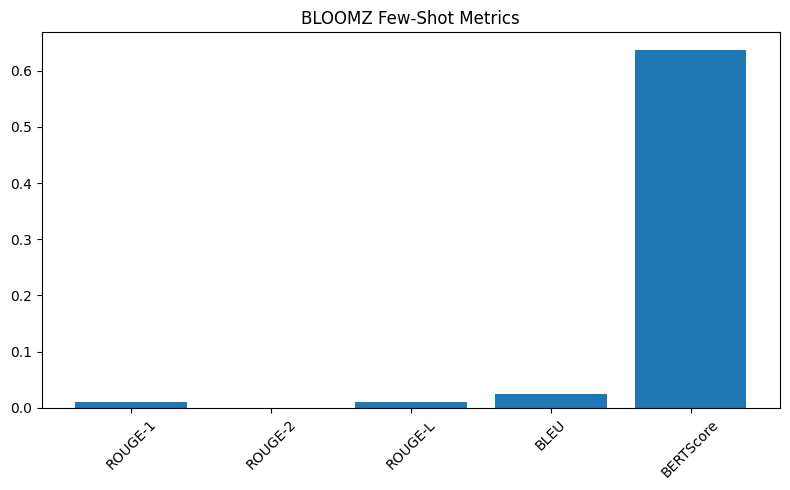

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(metrics_df["Metric"], metrics_df["Score"])
plt.title("BLOOMZ Few-Shot Metrics")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/bloomz_metrics_plot.png")
plt.show()

In [ ]:
sample_df.to_csv(
    f"{SAVE_DIR}/bloomz_sample_predictions.csv",
    index=False
)